# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the dataset in train, validate, and test sets
* Build the model
* Train the model
* Evaluate the model

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

2026-08-03 04:17:12.787085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785741433.586422  643619 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785741433.766941  643619 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-03 04:17:15.656016: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Flags
flag_load_model = False

In [3]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene02         0          0          0   
1  scene02         1          0         64   
2  scene02         2          0        128   
3  scene02         3          0        192   
4  scene02         4          0        256   

                                   x_patch_path  \
0  data/processed/scene02/images/patch_0000.npy   
1  data/processed/scene02/images/patch_0001.npy   
2  data/processed/scene02/images/patch_0002.npy   
3  data/processed/scene02/images/patch_0003.npy   
4  data/processed/scene02/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene02/masks/patch_0000.npy                14  
1  data/processed/scene02/masks/patch_0001.npy                84  
2  data/processed/scene02/masks/patch_0002.npy                70  
3  data/processed/scene02/masks/patch_0003.npy                 0  
4  data/processed/scene02/masks/patch_0004.npy                 0  
7623


## Separating the dataset in train, validate, and test sets

In [6]:
# Select the scenes for training, validation, and testing
train_scenes = [
    "scene01",
    "scene02",
    "scene03",
	"scene06",
	"scene07",
]

val_scenes = [
    "scene04",
]

test_scenes = [
    "scene05",
]

In [7]:
# Get the unique scene names
scenes = patch_index["scene"].unique()

# Select patches belonging to those scenes
train_df = patch_index[
    patch_index["scene"].isin(train_scenes)
].reset_index(drop=True)

val_df = patch_index[
    patch_index["scene"].isin(val_scenes)
].reset_index(drop=True)

test_df = patch_index[
    patch_index["scene"].isin(test_scenes)
].reset_index(drop=True)

In [8]:
# Show the number of patches for each scene
print("\nTraining")
print(train_df.groupby("scene").size())

print("\nValidation")
print(val_df.groupby("scene").size())

print("\nTesting")
print(test_df.groupby("scene").size())


Training
scene
scene01    1089
scene02    1089
scene03    1089
scene06    1089
scene07    1089
dtype: int64

Validation
scene
scene04    1089
dtype: int64

Testing
scene
scene05    1089
dtype: int64


In [9]:
# Show the number of patches for each scene and the mean sugarcane pixels
for scene in scenes:
	print(f"\nScene: {scene}")
	scene_df = patch_index[patch_index["scene"] == scene]
	print(scene_df.groupby("scene").size())
	print(scene_df["sugarcane_pixels"].mean())


Scene: scene02
scene
scene02    1089
dtype: int64
4640.149678604224

Scene: scene03
scene
scene03    1089
dtype: int64
5936.671258034894

Scene: scene05
scene
scene05    1089
dtype: int64
8867.149678604224

Scene: scene04
scene
scene04    1089
dtype: int64
7633.408631772269

Scene: scene06
scene
scene06    1089
dtype: int64
3389.1101928374655

Scene: scene07
scene
scene07    1089
dtype: int64
7379.667584940312

Scene: scene01
scene
scene01    1089
dtype: int64
9054.959595959595


In [10]:
# Show the mean number of sugarcane pixels for training, validation, and testing sets
print("Mean number of sugarcane pixels:")
print("Training:", train_df["sugarcane_pixels"].mean())
print("Validation:", val_df["sugarcane_pixels"].mean())
print("Testing:", test_df["sugarcane_pixels"].mean())

Mean number of sugarcane pixels:
Training: 6080.111662075298
Validation: 7633.408631772269
Testing: 8867.149678604224


In [11]:
# Calculate the positive ratio of sugarcane pixels for training, validation, and testing sets
train_positive_ratio = (train_df["sugarcane_pixels"].sum() / (len(train_df) * 128 * 128))
val_positive_ratio = (val_df["sugarcane_pixels"].sum() / (len(val_df) * 128 * 128))
test_positive_ratio = (test_df["sugarcane_pixels"].sum() / (len(test_df) * 128 * 128))

print("Training set positive ratio:  ", train_positive_ratio)
print("Validation set positive ratio:", val_positive_ratio)
print("Testing set positive ratio:   ", test_positive_ratio)

Training set positive ratio:   0.371100565312213
Validation set positive ratio: 0.4659062885603191
Testing set positive ratio:    0.5412078661257461


In [12]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [13]:
# Load the best hyperparameters from the JSON file
json_path = base_path / "models" / "best_sugarcane_params.json"

with open(json_path, "r") as f:
    saved_params = json.load(f)

In [14]:
# Function for data augmentation (flipping, mirroring and rotation)

def augment_patch(x, y):
    """
    x : (H,W,7)
    y : (H,W,1)
    """

    # Horizontal flip
    if random.random() < 0.5:
        x = np.flip(x, axis=1).copy()
        y = np.flip(y, axis=1).copy()

    # Vertical flip
    if random.random() < 0.5:
        x = np.flip(x, axis=0).copy()
        y = np.flip(y, axis=0).copy()

    # Random rotation (0,90,180,270)
    k = random.randint(0,3)
    x = np.rot90(x, k).copy()
    y = np.rot90(y, k).copy()

	# Random brightness adjustment - changes reflectances by ±10%.
    factor = np.random.uniform(0.9, 1.1)
    x = np.clip(x * factor, 0.0, 1.0)

    return x, y

In [15]:
# PatchGenerator class for generating batches of patches for training, validation, and testing
# So tehre is no need to load all patches into memory at once, which is useful for large datasets
class PatchGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        dataframe,
        base_path,
        batch_size=32,
        shuffle=True,
        compute_indices=True,
		augment=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.df = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.compute_indices = compute_indices

        self.augment = augment

        self.indexes = np.arange(len(self.df))

        self.on_epoch_end()


    def __len__(self):
        return (len(self.df) + self.batch_size - 1) // self.batch_size


    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.indexes)


    def __getitem__(self, batch_idx):

        start = batch_idx * self.batch_size
        end = min(start + self.batch_size, len(self.df))

        batch_indexes = self.indexes[start:end]

        X = []
        Y = []

        for idx in batch_indexes:

            row = self.df.iloc[idx]

            x_path = self.base_path / row["x_patch_path"]
            y_path = self.base_path / row["y_patch_path"]

            x = np.load(x_path)

            if x.dtype != np.float32:
                x = x.astype(np.float32)

            y = np.load(y_path)

            if y.dtype != np.float32:
                y = y.astype(np.float32)

            if self.augment:
                x, y = augment_patch(x, y)

            if self.compute_indices:
                x = add_spectral_indices(x)

            X.append(x)
            Y.append(y)

        return np.stack(X), np.stack(Y)

In [16]:
# Create instances of PatchGenerator for training, validation, and testing
train_generator = PatchGenerator(
    train_df,
    base_path,
    batch_size=saved_params["batch_size"],
    shuffle=True,
    compute_indices=True,
    augment=True
)

val_generator = PatchGenerator(
    val_df,
    base_path,
    batch_size=saved_params["batch_size"],
    shuffle=False,
    compute_indices=True,
    augment=True
)

test_generator = PatchGenerator(
    test_df,
    base_path,
    batch_size=saved_params["batch_size"],
    shuffle=False,
    compute_indices=True,
    augment=True
)

In [17]:
# Show the number of batches in training, validation, and testing sets
print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Testing batches:", len(test_generator))

Training batches: 86
Validation batches: 18
Testing batches: 18


In [18]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = train_generator[0]

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: float32
Training label data type: float32


## Build the Model

In [19]:
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [20]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [21]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [22]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model

In [23]:
# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

I0000 00:00:1785741530.736453  643619 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,024 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,941,681 (7.41 MB)

 Trainable params: 1,941,681 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# You can just load the model if already trained and not run again

history_dict = None  # Initialize history_dict to None

if flag_load_model:
	model_path = base_path / "models" / "unet_sugarcane.keras"
	history_path = base_path / "models" / "training_history.json"

	if model_path.exists():
		try:
			# Pass str(model_path) to ensure compatibility
			model = load_model(str(model_path), compile=False)
			print("Successfully loaded saved model.")
		except Exception as e:
			print(f"File exists, but load_model failed with error:\n{e}")
	else:
		print("File does not exist at the specified path. Check your working directory or base_path.")
	
	if history_path.exists():
		try:
			with open(str(history_path), 'r') as f:
				history_dict = json.load(f)
			print("Successfully loaded saved training history.")
		except Exception as e:
			print(f"File exists, but loading training history failed with error:\n{e}")
	else:
		print("Training history file does not exist at the specified path. Check your working directory or base_path.")
else:
	print("Model loading skipped. Training a new model from scratch using hyperparameter tuning results.")

Model loading skipped. Training a new model from scratch using hyperparameter tuning results.


## Train the model

In [25]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "unet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [26]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

In [28]:
# Train the model
if not flag_load_model:
	print("Training a new model.")
	history = model.fit(
		train_generator,
		validation_data=val_generator,
		epochs=50,
		callbacks=[checkpoint, early_stop, reduce_lr],
		verbose=1
	)

	history_dict = history.history
else:
	print("Model loaded, skipping training.")

Training a new model.
Epoch 1/50


I0000 00:00:1785741562.125242  694773 service.cc:148] XLA service 0x7f538800a0c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785741562.140362  694773 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-08-03 04:19:23.731662: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785741565.432125  694773 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1785741593.583317  694773 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


86/86 ━━━━━━━━━━━━━━━━━━━━ 554s 6s/step - binary_accuracy: 0.6402 - loss: 0.6272 - precision: 0.5456 - recall: 0.1824 - val_binary_accuracy: 0.5272 - val_loss: 0.5997 - val_precision: 0.4908 - val_recall: 0.3946 - learning_rate: 5.4084e-04
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - binary_accuracy: 0.6696 - loss: 0.5496 - precision: 0.5660 - recall: 0.4695 - val_binary_accuracy: 0.6338 - val_loss: 0.5729 - val_precision: 0.5887 - val_recall: 0.7105 - learning_rate: 5.4084e-04
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - binary_accuracy: 0.6741 - loss: 0.5573 - precision: 0.5655 - recall: 0.5254 - val_binary_accuracy: 0.5688 - val_loss: 0.5786 - val_precision: 0.5373 - val_recall: 0.5354 - learning_rate: 5.4084e-04
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - binary_accuracy: 0.7018 - loss: 0.5286 - precision: 0.5997 - recall: 0.5909 - val_binary_accuracy: 0.6907 - val_loss: 0.5502 - val_precision: 0.6266 - val_recall: 0.8319 - learning_rate: 5.4084e-04
Epoc

In [29]:
# Save the model and its history for future use.
# The model is saved in the Keras format (.keras) which includes both architecture and weights.

if not flag_load_model:
	# Save the model.
	model_path = base_path / "models" / "unet_sugarcane.keras"
	model.save(str(model_path))
	print(f"Model saved to '{model_path}'")

	# Save the training history as a JSON file for future reference.
	history_path = base_path / "models" / "training_history.json"
	with open(str(history_path), 'w') as f:
		json.dump(history_dict, f)
	print(f"Training history saved to '{history_path}'")
else:
	print("Model loaded, skipping saving model and history.")

Model saved to '/home/fdesmello/Git/spacesugar/models/unet_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar/models/training_history.json'


## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy.png'


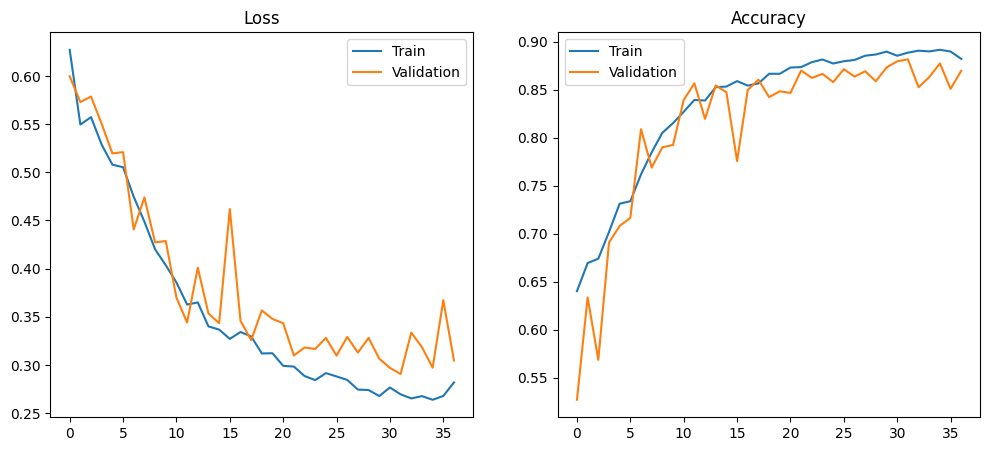

In [30]:
# Plot the learning curves

if history:
	plt.figure(figsize=(12,5))

	plt.subplot(1,2,1)
	plt.plot(history.history["loss"], label="Train")
	plt.plot(history.history["val_loss"], label="Validation")
	plt.title("Loss")
	plt.legend()

	plt.subplot(1,2,2)
	plt.plot(history.history["binary_accuracy"], label="Train")
	plt.plot(history.history["val_binary_accuracy"], label="Validation")
	plt.title("Accuracy")
	plt.legend()

	file_path = base_path / "figures" / "loss_accuracy.png"
	plt.savefig(file_path, dpi=300, bbox_inches='tight')
	print(f"\nVisualization saved as '{file_path}'")

	plt.show()
elif history_dict:
	plt.figure(figsize=(12,5))

	plt.subplot(1,2,1)
	plt.plot(history_dict["loss"], label="Train")
	plt.plot(history_dict["val_loss"], label="Validation")
	plt.title("Loss")
	plt.legend()

	plt.subplot(1,2,2)
	plt.plot(history_dict["binary_accuracy"], label="Train")
	plt.plot(history_dict["val_binary_accuracy"], label="Validation")
	plt.title("Accuracy")
	plt.legend()

	file_path = base_path / "figures" / "loss_accuracy.png"
	plt.savefig(file_path, dpi=300, bbox_inches='tight')
	print(f"\nVisualization saved as '{file_path}'")

	plt.show()
else:
	print("No training history available to plot learning curves.")

In [31]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb

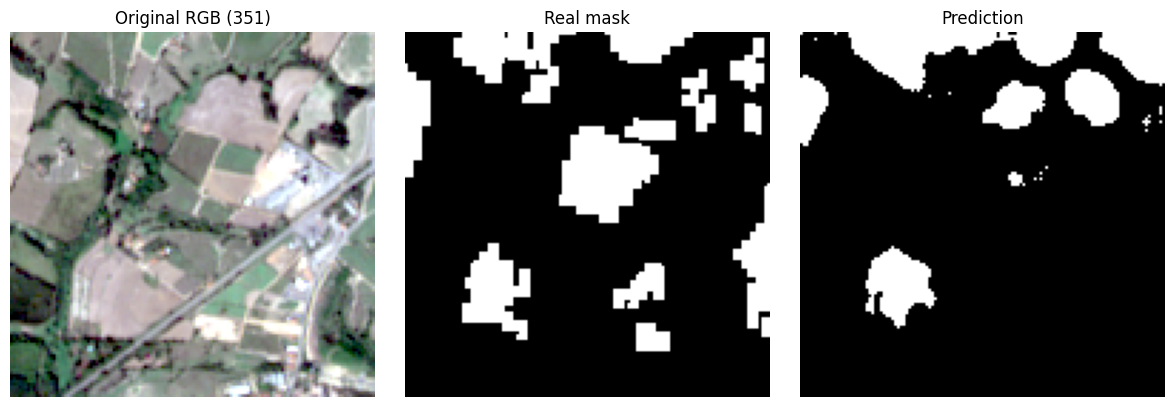

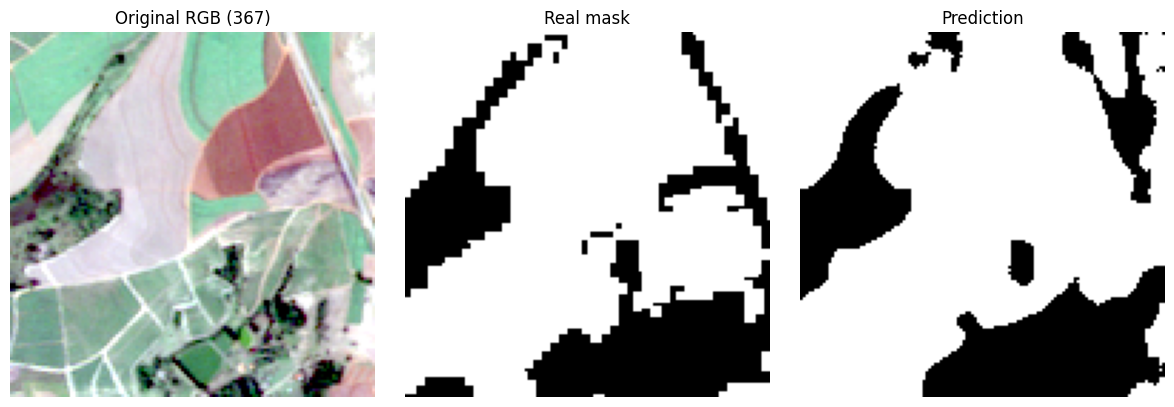

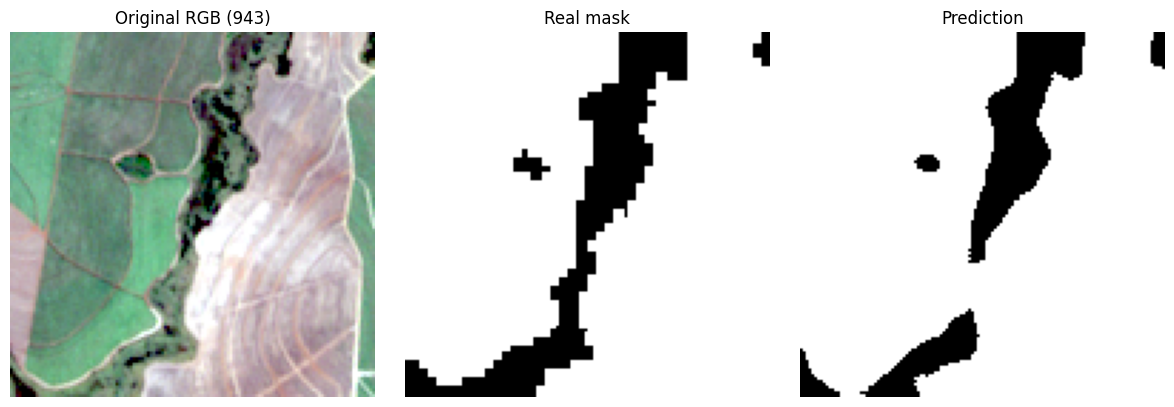

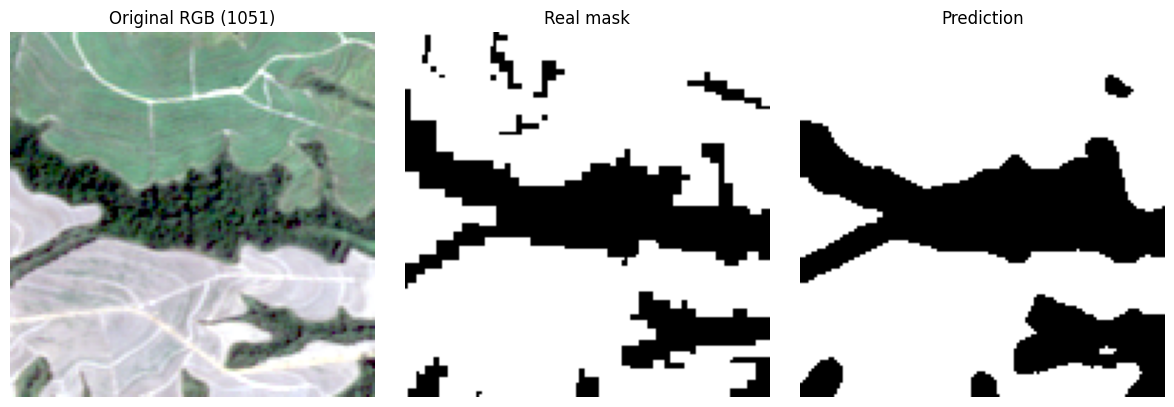

In [32]:
# Make all the predictions on the test set and visualize 4 random results

# Make predictions on the test set and visualize random results

max_plots = 4

all_targets = []
all_predictions = []

j = 0

# Number of patches in the whole test set
n_test = len(test_df)

# Global indices of the patches to visualize
plot_indices = set(random.sample(range(n_test), k=max_plots))

global_index = 0

for batch_idx in range(len(test_generator)):

    X_batch, y_batch = test_generator[batch_idx]

    # Predict the entire batch at once
    pred_batch = model.predict(X_batch, verbose=0)

    # Save predictions
    all_predictions.extend(pred_batch)
    all_targets.extend(y_batch)

    # Loop over images inside the batch
    for k in range(len(X_batch)):

        if global_index in plot_indices:

            pred = pred_batch[k]
            binary_pred = pred > 0.5

            fig, ax = plt.subplots(1, 3, figsize=(12, 4))

            # RGB visualization
            rgb = np.clip(X_batch[k][:, :, [2, 1, 0]], 0, 1).copy()

            rgb = stretch_rgb(rgb)

            ax[0].imshow(rgb)
            ax[0].set_title(f"Original RGB ({global_index})")
            ax[0].axis("off")

            ax[1].imshow(y_batch[k].squeeze(), cmap="gray")
            ax[1].set_title("Real mask")
            ax[1].axis("off")

            ax[2].imshow(binary_pred.squeeze(), cmap="gray")
            ax[2].set_title("Prediction")
            ax[2].axis("off")

            file_path = (base_path / "figures" / f"unet_sugarcane_results_{j}.png")

            plt.tight_layout()
            plt.savefig(file_path, dpi=300, bbox_inches="tight")
            plt.show()

            j += 1

        global_index += 1

In [33]:
# Metrics Calculation

# 1. Collect predictions into a matching NumPy array
y_pred_all = np.array(all_predictions)
y_true_all = np.array(all_targets)

# 2. Convert probabilities to binary masks
y_pred_bin = (y_pred_all > 0.5).astype(np.uint8)
y_true_bin = y_true_all.astype(np.uint8)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_true_all.ravel()
y_pred_float = y_pred_all.ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the test dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Intersection over Union (IoU) for the sugarcane class
# Instantiate the metric object
# target_class_ids=[1] isolates the sugarcane class, ignoring background pixels
iou_metric = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)

# Update the metric state with true masks and predicted probabilities
iou_metric.update_state(y_true_flat, y_pred_flat)

# Extract and print the final result
final_iou = iou_metric.result().numpy()
print(f"IoU: {final_iou:.4f}")

# 6. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))

Metrics for the test dataset:
Precision: 0.8911
Recall: 0.7877
F1-Score: 0.8362
ROC AUC Score: 0.8371
IoU: 0.7185

Confusion Matrix:
[[7255946  929904]
 [2049738 7606588]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83   8185850
           1       0.89      0.79      0.84   9656326

    accuracy                           0.83  17842176
   macro avg       0.84      0.84      0.83  17842176
weighted avg       0.84      0.83      0.83  17842176



/tmp/ipykernel_643619/200001336.py:81: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results.png'


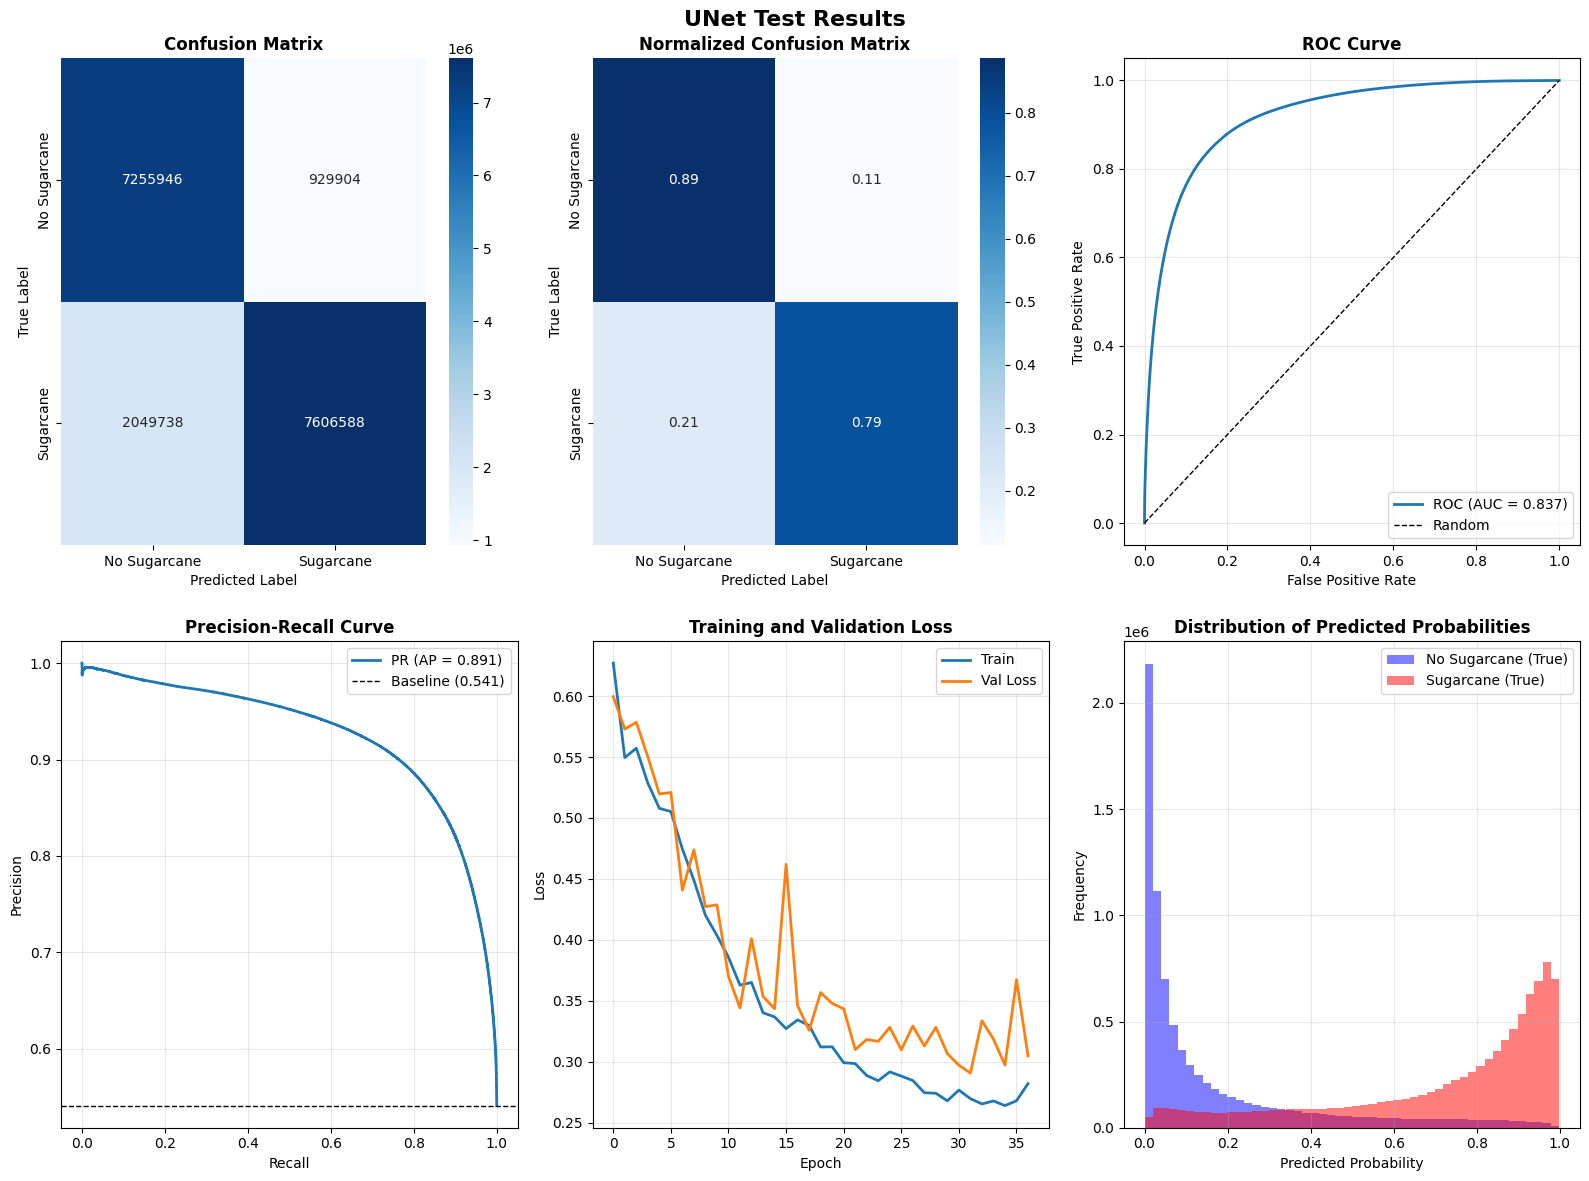

In [35]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
if history is not None:
	hist = history.history
	ax5 = plt.subplot(2, 3, 5)
	ax5.plot(history.history["loss"], label="Train", linewidth=2)
	ax5.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
	ax5.set_xlabel('Epoch')
	ax5.set_ylabel('Loss')
	ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
	ax5.legend()
	ax5.grid(True, alpha=0.3)
elif history_dict is not None:
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(history_dict["loss"], label='Train Loss', linewidth=2)
    ax5.plot(history_dict["val_loss"], label='Val Loss', linewidth=2)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)


# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
#ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()